In [1]:
!git clone --depth 1 https://github.com/realshubhamraut/CDAC-DBDA-coursework.git


!mkdir -p /content/data

!cp -r CDAC-DBDA-coursework/08.advanced-analytics-stats/data/* /content/data/

!ls -lh /content/data


Cloning into 'CDAC-DBDA-coursework'...
remote: Enumerating objects: 2118, done.
remote: Counting objects: 100% (2118/2118), done.
remote: Compressing objects: 100% (1824/1824), done.
remote: Total 2118 (delta 233), reused 2006 (delta 212), pack-reused 0 (from 0)
Receiving objects: 100% (2118/2118), 809.48 MiB | 30.00 MiB/s, done.
Resolving deltas: 100% (233/233), done.
Updating files: 100% (1975/1975), done.
Filtering content: 100% (124/124), 1.10 GiB | 66.86 MiB/s, done.
total 565M
-rw-r--r-- 1 root root  23K Dec 15 06:25  AlgeriaFire.xlsx
-rw-r--r-- 1 root root 119K Dec 15 06:25  CDAC_DataBook.xlsx
-rw-r--r-- 1 root root 669K Dec 15 06:25  Churn_Modelling.csv
-rw-r--r-- 1 root root 8.7K Dec 15 06:25  covid_cases.xlsx
-rw-r--r-- 1 root root 159M Dec 15 06:25  credit_risk_applicants.csv
-rw-r--r-- 1 root root  28K Dec 15 06:25  credit_risk_metadata.csv
-rw-r--r-- 1 root root 387M Dec 15 06:25  credit_risk_previous_loans.csv
-rw-r--r-- 1 root root  44K Dec 15 06:25  Delivery_Food.csv
-r

In [3]:
import pandas as pd

In [4]:
df = pd.read_excel('data/titanic_dataset.xlsx')

In [5]:
df.head()

,Pclass,Survived,Name,Gender,Age,SiblingCount,ParentsCount,Ticket,Fare,Embarked
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,S
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,S
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,S
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,S
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,S


In [6]:
df = df.drop(['Name','Ticket'], axis=1)  # removing the unwanted columns

In [7]:
df.isnull().sum()   # to check total number of missing values


,0
Pclass,0
Survived,0
Gender,0
Age,263
SiblingCount,0
ParentsCount,0
Fare,1
Embarked,2


In [8]:
df.Age = df.Age.fillna(df.Age.median())   # fill missing values for Age with the median


In [9]:
df.Fare = df.Fare.fillna(df.Fare.median()) # fill missing values for Fare with the median


In [10]:
df.Embarked = df.Embarked.fillna('S')   # fill missing values for Embarked with the mode

In [11]:
df.head()

,Pclass,Survived,Gender,Age,SiblingCount,ParentsCount,Fare,Embarked
0,1,1,female,29.0000,0,0,211.3375,S
1,1,1,male,0.9167,1,2,151.5500,S
2,1,0,female,2.0000,1,2,151.5500,S
3,1,0,male,30.0000,1,2,151.5500,S
4,1,0,female,25.0000,1,2,151.5500,S


In [13]:
df.where(df.Fare>120)

,Pclass,Survived,Gender,Age,SiblingCount,ParentsCount,Fare,Embarked
0,1.0,1.0,female,29.0000,0.0,0.0,211.3375,S
1,1.0,1.0,male,0.9167,1.0,2.0,151.5500,S
2,1.0,0.0,female,2.0000,1.0,2.0,151.5500,S
3,1.0,0.0,male,30.0000,1.0,2.0,151.5500,S
4,1.0,0.0,female,25.0000,1.0,2.0,151.5500,S
...,...,...,...,...,...,...,...,...
1304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1305,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1306,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df.shape

(1309, 8)

In [15]:
df['TotalPassengers'] =df['SiblingCount'] + df['ParentsCount'] + 1


In [16]:
df = df.drop(['SiblingCount','ParentsCount'], axis=1)

In [17]:
df.head()

,Pclass,Survived,Gender,Age,Fare,Embarked,TotalPassengers
0,1,1,female,29.0000,211.3375,S,1
1,1,1,male,0.9167,151.5500,S,4
2,1,0,female,2.0000,151.5500,S,4
3,1,0,male,30.0000,151.5500,S,4
4,1,0,female,25.0000,151.5500,S,4


In [18]:
# decision trees and random forest are not affected by outliers, and they do not require standardization at any point

In [19]:
class_dum = pd.get_dummies(df.Pclass, drop_first=True,prefix='Class').astype(int)
gen_dum = pd.get_dummies(df.Gender, drop_first=True,prefix='Gender').astype(int)
emb_dum = pd.get_dummies(df.Embarked, drop_first=True,prefix='Embark').astype(int)
TotPass_dum = pd.get_dummies(df.TotalPassengers, drop_first=True,prefix='TotPass').astype(int)

df = df.drop(['Pclass','Gender','Embarked','TotalPassengers'], axis=1)

df = pd.concat([df,class_dum,gen_dum,emb_dum,TotPass_dum], axis=1)

In [20]:
df.head()

,Survived,Age,Fare,Class_2,Class_3,Gender_male,Embark_Q,Embark_S,TotPass_2,TotPass_3,TotPass_4,TotPass_5,TotPass_6,TotPass_7,TotPass_8,TotPass_11
0,1,29.0000,211.3375,0,0,0,0,1,0,0,0,0,0,0,0,0
1,1,0.9167,151.5500,0,0,1,0,1,0,0,1,0,0,0,0,0
2,0,2.0000,151.5500,0,0,0,0,1,0,0,1,0,0,0,0,0
3,0,30.0000,151.5500,0,0,1,0,1,0,0,1,0,0,0,0,0
4,0,25.0000,151.5500,0,0,0,0,1,0,0,1,0,0,0,0,0


In [24]:
from sklearn import *
dtc = DecisionTreeClassifier()

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('Survived', axis=1), df.Survived, test_size=0.15, random_state=20)

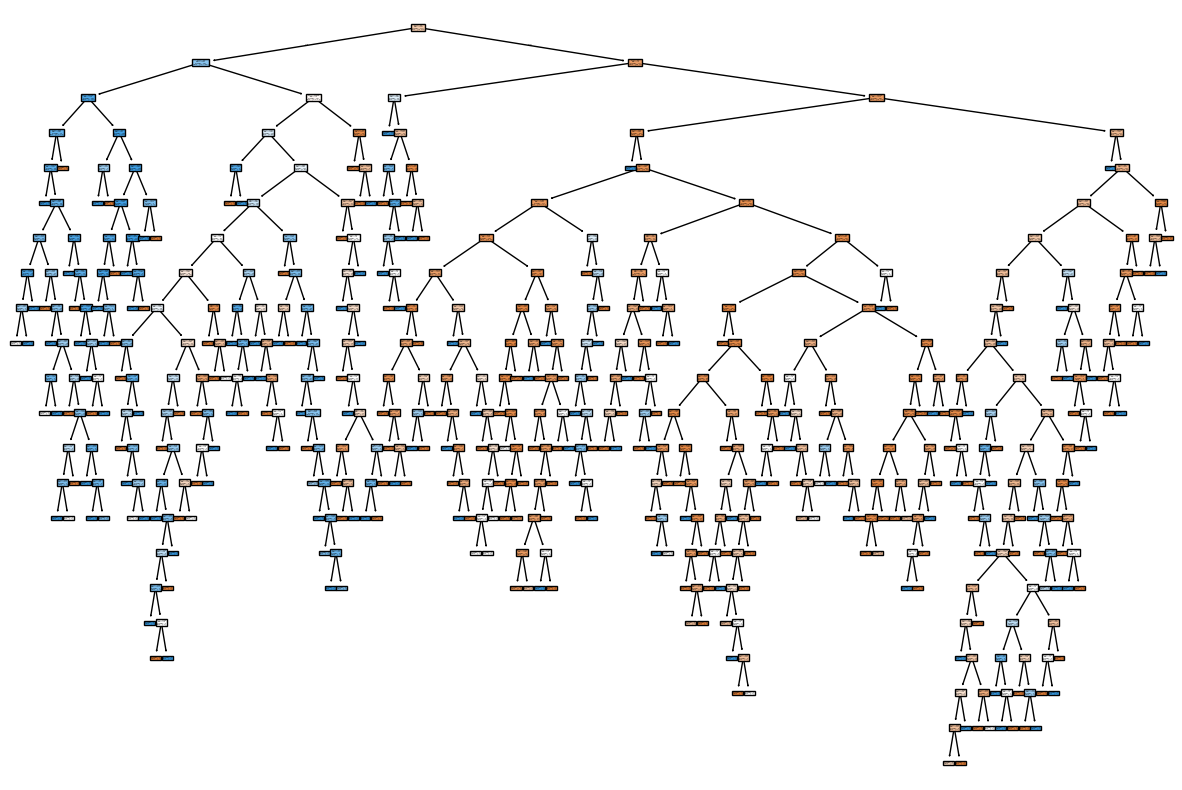

In [30]:
import matplotlib.pyplot as plt
mod1 = dtc.fit(x_train, y_train)
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc,filled=True) 
plt.show()

In [32]:
from sklearn.metrics import confusion_matrix
y_pred_train = mod1.predict(x_train)
print(confusion_matrix(y_train,y_pred_train))

[[689   9]
 [ 27 387]]


In [33]:
(689+387) / (689 + 387 + 36)

0.9676258992805755

In [34]:
dtc.score(x_train, y_train)

0.9676258992805755

In [35]:
y_pred_test = mod1.predict(x_test)

In [36]:
print(confusion_matrix(y_test, y_pred_test))

[[98 13]
 [30 56]]


In [37]:
(98+56) / (98+56 + 45)

0.7738693467336684

In [ ]:
# incase of decision tress if no parameters are given it will always result in overfitting

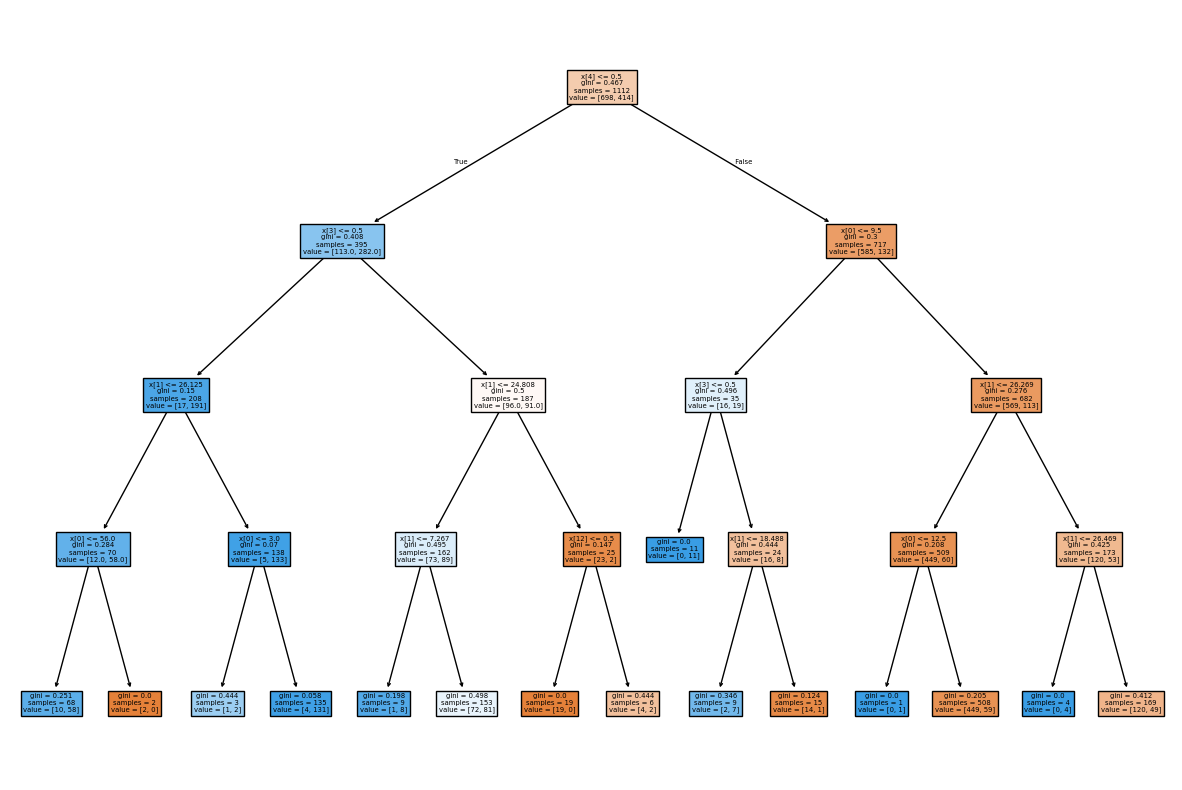

[[689   9]
 [ 27 387]]
[[98 13]
 [30 56]]


0.8020304568527918

In [39]:
dtc2 = DecisionTreeClassifier(max_depth=4)

mod2 = dtc2.fit(x_train, y_train)
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(dtc2,filled=True) 
plt.show()

y_pred_train2 = mod2.predict(x_train)
print(confusion_matrix(y_train,y_pred_train))
dtc2.score(x_train,y_train)

y_pred_test2 = mod2.predict(x_test)
print(confusion_matrix(y_test,y_pred_test))
dtc2.score(x_test,y_test)

In [1]:
y = 6
n = 4

In [5]:
round(0.9 * 0.1,2)

0.09

In [7]:
prob1 = 0.16667
prob2 = 0.8333

In [ ]:
prob